Component        Mean      Std   Weight    AUC (numerical)   AUC (analytical)
----------------------------------------------------------------------------
  Comp 1        6.073    0.686    0.202           0.202029           0.202029
  Comp 2       -2.011    0.479    0.298           0.298126           0.298126
  Comp 3        1.971    0.985    0.500           0.499837           0.499837
----------------------------------------------------------------------------
  Mixture                                         0.999991   (= sum of weights ~ 1)


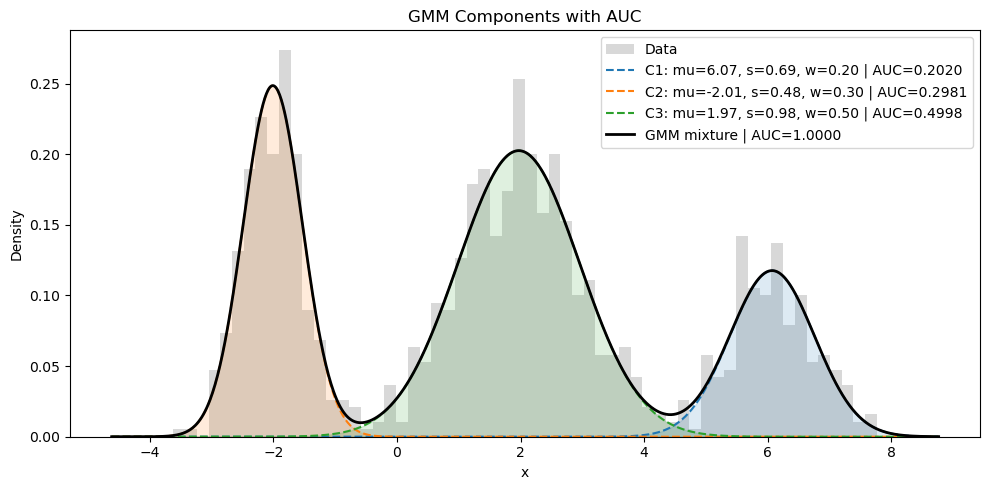

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture

# --- Fit GMM ---
np.random.seed(42)
X = np.concatenate([
    np.random.normal(-2, 0.5, 300),
    np.random.normal(2, 1.0, 500),
    np.random.normal(6, 0.7, 200)
]).reshape(-1, 1)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# --- Plot ---
x = np.linspace(X.min() - 1, X.max() + 1, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(X, bins=60, density=True, alpha=0.3, color='gray', label='Data')

colors = plt.cm.tab10.colors
mixture_pdf = np.zeros_like(x)

print(f"{'Component':<12} {'Mean':>8} {'Std':>8} {'Weight':>8} {'AUC (numerical)':>18} {'AUC (analytical)':>18}")
print("-" * 76)

for i, (mean, cov, weight) in enumerate(zip(gmm.means_, gmm.covariances_, gmm.weights_)):
    mu  = mean[0]
    std = np.sqrt(cov[0, 0])

    pdf = weight * stats.norm.pdf(x, mu, std)
    mixture_pdf += pdf

    auc_numerical  = np.trapezoid(pdf, x)
    auc_analytical = weight * (stats.norm.cdf(x[-1], mu, std)
                              - stats.norm.cdf(x[0],  mu, std))

    print(f"  Comp {i+1}     {mu:>8.3f} {std:>8.3f} {weight:>8.3f} "
          f"{auc_numerical:>18.6f} {auc_analytical:>18.6f}")

    ax.fill_between(x, pdf, alpha=0.15, color=colors[i])
    ax.plot(x, pdf, '--', color=colors[i],
            label=f'C{i+1}: mu={mu:.2f}, s={std:.2f}, w={weight:.2f} | AUC={auc_analytical:.4f}')

total_auc = np.trapezoid(mixture_pdf, x)
print("-" * 76)
print(f"  {'Mixture':<10} {'':>8} {'':>8} {'':>8} {total_auc:>18.6f}   (= sum of weights ~ 1)")

ax.plot(x, mixture_pdf, 'k-', lw=2, label=f'GMM mixture | AUC={total_auc:.4f}')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('GMM Components with AUC')
ax.legend()
plt.tight_layout()
plt.show()

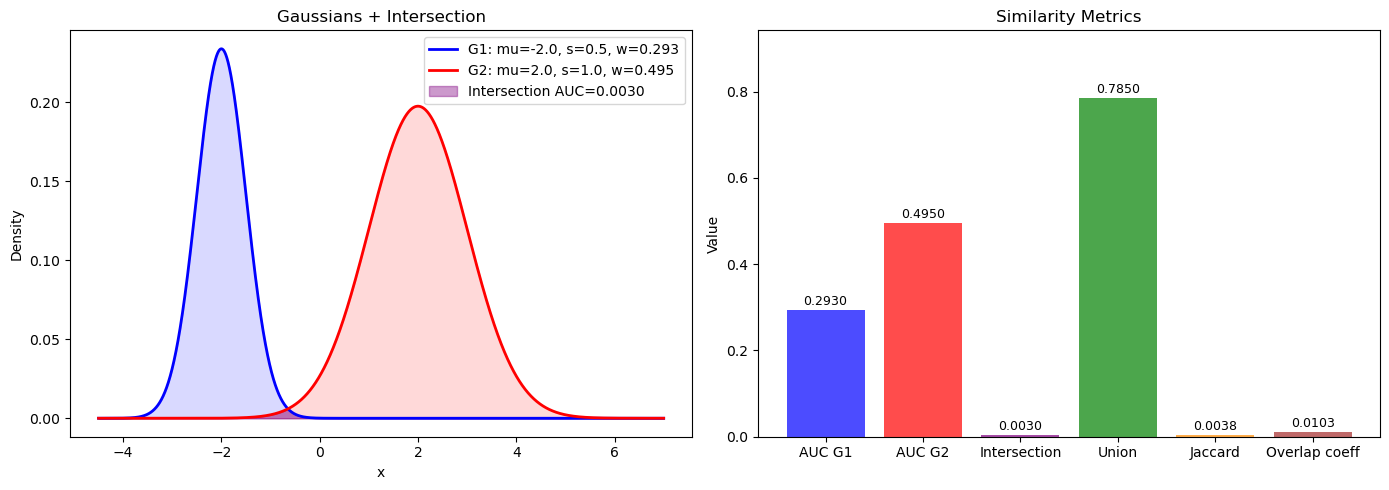


  AUC G1            : 0.293000
  AUC G2            : 0.495000
  Intersection AUC  : 0.003008
  Union AUC         : 0.784992
  Jaccard similarity: 0.003831  (0=no overlap, 1=identical)
  Overlap coeff     : 0.010265  (1= one contained in other)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:
    trapz = np.trapezoid
except AttributeError:
    trapz = np.trapz

def gaussian_similarity(mu1, std1, w1, mu2, std2, w2, n_points=10000):
    """
    Similarity between 2 weighted gaussians = intersection AUC / union AUC
    (Jaccard-like metric on probability densities)
    """
    # Wide enough range to capture both distributions
    x_min = min(mu1 - 5*std1, mu2 - 5*std2)
    x_max = max(mu1 + 5*std1, mu2 + 5*std2)
    x = np.linspace(x_min, x_max, n_points)

    pdf1 = w1 * stats.norm.pdf(x, mu1, std1)
    pdf2 = w2 * stats.norm.pdf(x, mu2, std2)

    # Intersection: min of the two PDFs at each point
    intersection = np.minimum(pdf1, pdf2)

    # Union: max of the two PDFs at each point
    union = np.maximum(pdf1, pdf2)

    auc1          = trapz(pdf1, x)
    auc2          = trapz(pdf2, x)
    auc_intersect = trapz(intersection, x)
    auc_union     = trapz(union, x)

    # Jaccard-like: intersection / union
    jaccard    = auc_intersect / auc_union

    # Overlap coefficient: intersection / min(auc1, auc2)  — more sensitive
    overlap    = auc_intersect / min(auc1, auc2)

    return x, pdf1, pdf2, intersection, union, {
        'auc1':          auc1,
        'auc2':          auc2,
        'auc_intersect': auc_intersect,
        'auc_union':     auc_union,
        'jaccard':       jaccard,
        'overlap':       overlap,
    }


def plot_similarity(mu1, std1, w1, mu2, std2, w2):
    x, pdf1, pdf2, intersection, union, m = gaussian_similarity(
        mu1, std1, w1, mu2, std2, w2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left: PDFs + intersection ---
    ax = axes[0]
    ax.plot(x, pdf1, 'b-',  lw=2, label=f'G1: mu={mu1}, s={std1}, w={w1}')
    ax.plot(x, pdf2, 'r-',  lw=2, label=f'G2: mu={mu2}, s={std2}, w={w2}')
    ax.fill_between(x, intersection, alpha=0.4, color='purple', label=f'Intersection AUC={m["auc_intersect"]:.4f}')
    ax.fill_between(x, pdf1, alpha=0.15, color='blue')
    ax.fill_between(x, pdf2, alpha=0.15, color='red')
    ax.set_title('Gaussians + Intersection')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend()

    # --- Right: metrics bar chart ---
    ax2 = axes[1]
    labels = ['AUC G1', 'AUC G2', 'Intersection', 'Union', 'Jaccard', 'Overlap coeff']
    values = [m['auc1'], m['auc2'], m['auc_intersect'], m['auc_union'],
              m['jaccard'], m['overlap']]
    bar_colors = ['blue', 'red', 'purple', 'green', 'darkorange', 'brown']
    bars = ax2.bar(labels, values, color=bar_colors, alpha=0.7)
    ax2.set_ylim(0, max(values) * 1.2)
    ax2.set_title('Similarity Metrics')
    ax2.set_ylabel('Value')
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\n  AUC G1            : {m['auc1']:.6f}")
    print(f"  AUC G2            : {m['auc2']:.6f}")
    print(f"  Intersection AUC  : {m['auc_intersect']:.6f}")
    print(f"  Union AUC         : {m['auc_union']:.6f}")
    print(f"  Jaccard similarity: {m['jaccard']:.6f}  (0=no overlap, 1=identical)")
    print(f"  Overlap coeff     : {m['overlap']:.6f}  (1= one contained in other)")

    return m


# --- Example: compare two GMM components ---
m = plot_similarity(mu1=-2.0, std1=0.5, w1=0.293,
                    mu2= 2.0, std2=1.0, w2=0.495)


Step   GMM-A comp GMM-B comp    AUC_A    AUC_B    Jaccard
--------------------------------------------------------
  1     A[0] -> B[0]     0.3858   0.4473   0.561297
  2     A[1] -> B[1]     0.3758   0.3000   0.168696
  3     A[2] -> B[2]     0.2384   0.2527   0.411067
--------------------------------------------------------
  Raw Jaccard score     : 1.141061
  Max possible (matched): 3
  Normalized score [0,1]: 0.380354



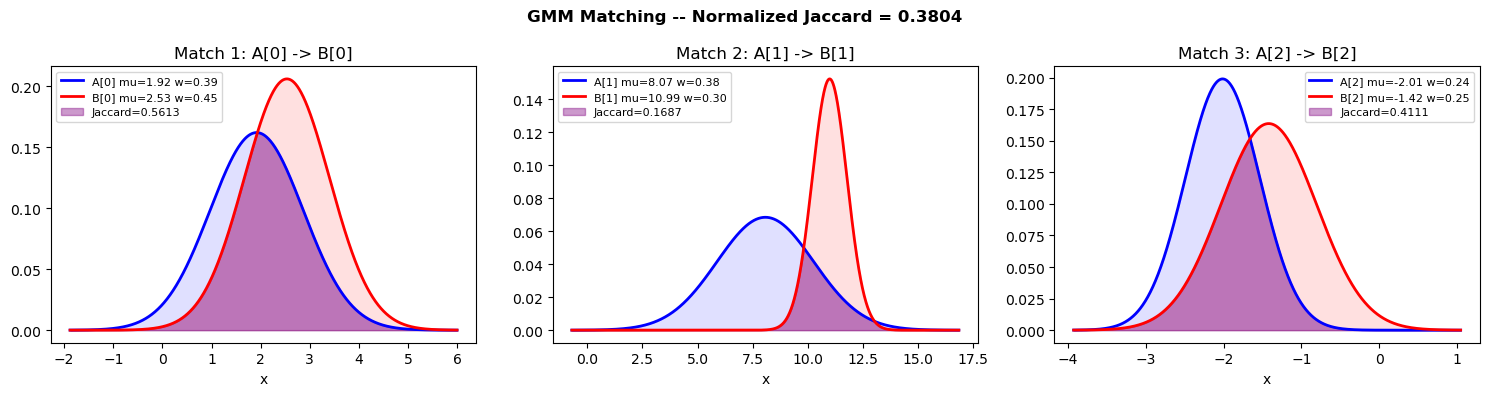

'\nThe algorithm flow:\n \ncomps_a sorted by AUC desc:  [A0, A1, A2]\ncomps_b sorted by AUC desc:  [B0, B1, B2]\n\nStep 1: A0 (highest AUC) → best Jaccard match in {B0,B1,B2} → say B1\nStep 2: A1               → best Jaccard match in {B0,B2}    → say B0\nStep 3: A2               → best Jaccard match in {B2}        → B2\n─────────────────────────────────────────────────────────────\nTotal score = J(A0,B1) + J(A1,B0) + J(A2,B2)   ∈ [0, n_components]\n'

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture

try:
    trapz = np.trapezoid
except AttributeError:
    trapz = np.trapz

# ─────────────────────────────────────────────
# Core: AUC of a single weighted gaussian
# ─────────────────────────────────────────────
def gaussian_auc(mu, std, weight, x):
    return trapz(weight * stats.norm.pdf(x, mu, std), x)

# ─────────────────────────────────────────────
# Core: Jaccard between 2 weighted gaussians
# ─────────────────────────────────────────────
def jaccard(mu1, std1, w1, mu2, std2, w2, n_points=10000):
    x_min = min(mu1 - 5*std1, mu2 - 5*std2)
    x_max = max(mu1 + 5*std1, mu2 + 5*std2)
    x = np.linspace(x_min, x_max, n_points)
    pdf1 = w1 * stats.norm.pdf(x, mu1, std1)
    pdf2 = w2 * stats.norm.pdf(x, mu2, std2)
    auc_union = trapz(np.maximum(pdf1, pdf2), x)
    if auc_union == 0:
        return 0.0
    return trapz(np.minimum(pdf1, pdf2), x) / auc_union

# ─────────────────────────────────────────────
# Extract components from a fitted GMM
# returns list of (mu, std, weight, auc) dicts
# ─────────────────────────────────────────────
def extract_components(gmm):
    x_ref = np.linspace(-20, 20, 10000)
    components = []
    for mean, cov, weight in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        mu  = mean[0]
        std = np.sqrt(cov[0, 0])
        components.append({'mu': mu, 'std': std, 'weight': weight})

    # Normalize weights so total AUC = 1.0
    total_auc = sum(
        trapz(c['weight'] * stats.norm.pdf(x_ref, c['mu'], c['std']), x_ref)
        for c in components
    )
    for c in components:
        c['weight'] = c['weight'] / total_auc
        c['auc']    = trapz(c['weight'] * stats.norm.pdf(x_ref, c['mu'], c['std']), x_ref)

    return components

# ─────────────────────────────────────────────
# Main similarity metric
# ─────────────────────────────────────────────
def gmm_similarity(gmm_a, gmm_b, verbose=True):
    """
    Greedy AUC-sorted Jaccard matching between two GMMs.
    Returns cumulative Jaccard score and the match list.
    """
    comps_a = sorted(extract_components(gmm_a), key=lambda c: c['auc'], reverse=True)
    comps_b = sorted(extract_components(gmm_b), key=lambda c: c['auc'], reverse=True)

    remaining_b = list(range(len(comps_b)))  # indices into comps_b still available
    matches     = []
    total_score = 0.0

    if verbose:
        print(f"\n{'Step':<6} {'GMM-A comp':>10} {'GMM-B comp':>10} "
              f"{'AUC_A':>8} {'AUC_B':>8} {'Jaccard':>10}")
        print("-" * 56)

    for i, ca in enumerate(comps_a):
        if not remaining_b:
            if verbose:
                print(f"  {i+1:<5} A[{i}] unmatched (no B components left)")
            break

        # Find best Jaccard match among remaining B components
        best_j, best_idx = -1.0, None
        for j in remaining_b:
            cb  = comps_b[j]
            jac = jaccard(ca['mu'], ca['std'], ca['weight'],
                          cb['mu'], cb['std'], cb['weight'])
            if jac > best_j:
                best_j, best_idx = jac, j

        cb = comps_b[best_idx]
        matches.append({'a': i, 'b': best_idx,
                        'ca': ca, 'cb': cb, 'jaccard': best_j})
        total_score += best_j
        remaining_b.remove(best_idx)

        if verbose:
            print(f"  {i+1:<5} A[{i}] -> B[{best_idx}]   "
                  f"{ca['auc']:>8.4f} {cb['auc']:>8.4f} {best_j:>10.6f}")

    n_matched = min(len(comps_a), len(comps_b))
    normalized_score = total_score / n_matched if n_matched > 0 else 0.0

    if verbose:
        print("-" * 56)
        print(f"  Raw Jaccard score     : {total_score:.6f}")
        print(f"  Max possible (matched): {n_matched}")
        print(f"  Normalized score [0,1]: {normalized_score:.6f}\n")

    return normalized_score, total_score, matches
# ─────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────
def plot_gmm_matching(gmm_a, gmm_b, matches):
    comps_a = sorted(extract_components(gmm_a), key=lambda c: c['auc'], reverse=True)
    comps_b = sorted(extract_components(gmm_b), key=lambda c: c['auc'], reverse=True)

    n = len(matches)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, m in zip(axes, matches):
        ca, cb = m['ca'], m['cb']
        x_min = min(ca['mu'] - 4*ca['std'], cb['mu'] - 4*cb['std'])
        x_max = max(ca['mu'] + 4*ca['std'], cb['mu'] + 4*cb['std'])
        x = np.linspace(x_min, x_max, 2000)

        pdf_a = ca['weight'] * stats.norm.pdf(x, ca['mu'], ca['std'])
        pdf_b = cb['weight'] * stats.norm.pdf(x, cb['mu'], cb['std'])

        ax.plot(x, pdf_a, 'b-', lw=2,
                label=f"A[{m['a']}] mu={ca['mu']:.2f} w={ca['weight']:.2f}")
        ax.plot(x, pdf_b, 'r-', lw=2,
                label=f"B[{m['b']}] mu={cb['mu']:.2f} w={cb['weight']:.2f}")
        ax.fill_between(x, np.minimum(pdf_a, pdf_b),
                        alpha=0.4, color='purple',
                        label=f"Jaccard={m['jaccard']:.4f}")
        ax.fill_between(x, pdf_a, alpha=0.12, color='blue')
        ax.fill_between(x, pdf_b, alpha=0.12, color='red')
        ax.set_title(f"Match {m['a']+1}: A[{m['a']}] -> B[{m['b']}]")
        ax.set_xlabel('x')
        ax.legend(fontsize=8)

    plt.suptitle(f"GMM Matching -- Normalized Jaccard = {sum(m['jaccard'] for m in matches) / len(matches):.4f}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

def check_normalization(gmm, tol=1e-4):
    x_ref = np.linspace(-20, 20, 10000)
    comps = extract_components(gmm)
    total = sum(
        trapz(c['weight'] * stats.norm.pdf(x_ref, c['mu'], c['std']), x_ref)
        for c in comps
    )
    ok = abs(total - 1.0) < tol
    return ok, total
# ─────────────────────────────────────────────
# Demo: two different GMMs
# ─────────────────────────────────────────────
np.random.seed(42)

# GMM A — 3 components
X_a = np.concatenate([
    np.random.normal(-2, 0.5, 300),
    np.random.normal( 2, 1.0, 500),
    np.random.normal( 6, 0.7, 200),
    np.random.normal( 10, 0.2, 250),
]).reshape(-1, 1)

# GMM B — 3 components, shifted
X_b = np.concatenate([
    np.random.normal(-1.5, 0.6, 250),
    np.random.normal( 2.5, 0.9, 450),
    np.random.normal( 11.0, 0.8, 300),
]).reshape(-1, 1)

gmm_a = GaussianMixture(n_components=3, random_state=42).fit(X_a)
gmm_b = GaussianMixture(n_components=3, random_state=42).fit(X_b)

score, raw_score, matches = gmm_similarity(gmm_a, gmm_b)
plot_gmm_matching(gmm_a, gmm_b, matches)

'''
The algorithm flow:
 
comps_a sorted by AUC desc:  [A0, A1, A2]
comps_b sorted by AUC desc:  [B0, B1, B2]

Step 1: A0 (highest AUC) → best Jaccard match in {B0,B1,B2} → say B1
Step 2: A1               → best Jaccard match in {B0,B2}    → say B0
Step 3: A2               → best Jaccard match in {B2}        → B2
─────────────────────────────────────────────────────────────
Total score = J(A0,B1) + J(A1,B0) + J(A2,B2)   ∈ [0, n_components]
'''


  GMM SIMILARITY TEST SUITE

--- GROUP 0: Normalization sanity check ---
  [PASS]  Total AUC 1-component         : 1.00000000
  [PASS]  Total AUC 3-component         : 1.00000000
  [PASS]  Total AUC unequal sizes       : 1.00000000
  [PASS]  Total AUC 4-component         : 1.00000000

--- GROUP 1: Identity & near-identity ---
  [PASS]  Identical single gaussian                     score=1.0000  expected=[0.99, 1.00]
  [PASS]  Identical 3-component GMM                     score=1.0000  expected=[0.99, 1.00]
  [PASS]  Near-identical single gaussian (shift=0.1)    score=0.9101  expected=[0.85, 1.00]
  [PASS]  Near-identical 3-component (shift=0.1)        score=0.8806  expected=[0.80, 1.00]

--- GROUP 2: No overlap (should score near 0) ---
  [PASS]  Single gaussians far apart (dist=20)          score=0.0000  expected=[0.00, 0.01]
  [PASS]  3-component GMMs fully separated              score=0.0000  expected=[0.00, 0.02]

--- GROUP 3: Partial overlap ---
  [PASS]  Single gaussian shift=1 s

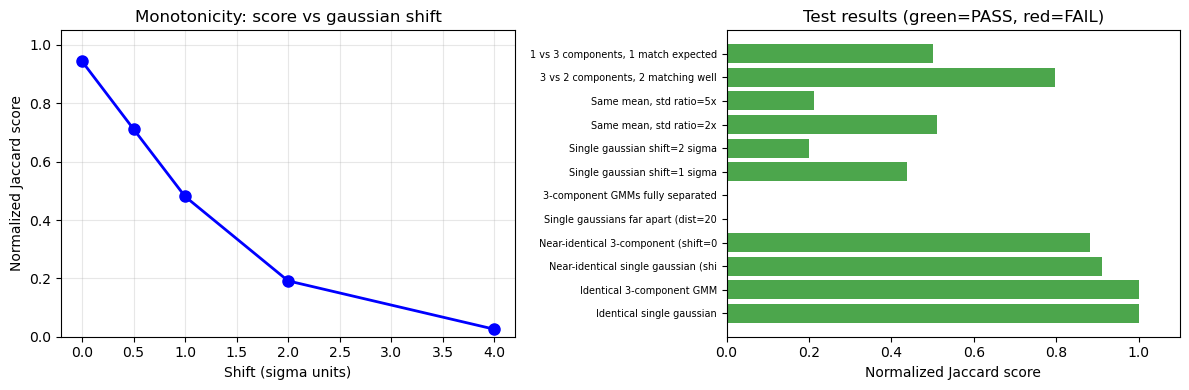

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture

try:
    trapz = np.trapezoid
except AttributeError:
    trapz = np.trapz

# ── paste your functions here (gaussian_auc, jaccard, extract_components,
#    gmm_similarity, plot_gmm_matching) or run them in a prior cell ──

def fit_gmm(data_list, n_components):
    X = np.concatenate(data_list).reshape(-1, 1)
    return GaussianMixture(n_components=n_components, random_state=42).fit(X)

def run_test(name, gmm_a, gmm_b, expected_range, verbose=False):
    score, raw, matches = gmm_similarity(gmm_a, gmm_b, verbose=verbose)
    lo, hi = expected_range
    passed = lo <= score <= hi
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}]  {name:<45} score={score:.4f}  expected=[{lo:.2f}, {hi:.2f}]")
    return {'name': name, 'score': score, 'passed': passed, 'matches': matches,
            'gmm_a': gmm_a, 'gmm_b': gmm_b}

np.random.seed(42)
results = []
print("=" * 75)
print("  GMM SIMILARITY TEST SUITE")
print("=" * 75)
print("\n--- GROUP 0: Normalization sanity check ---")

test_gmms = {
    "1-component"  : fit_gmm([np.random.normal(0, 1, 500)], 1),
    "3-component"  : fit_gmm([np.random.normal(-3,0.5,300),
                               np.random.normal( 0,1.0,500),
                               np.random.normal( 3,0.5,200)], 3),
    "unequal sizes": fit_gmm([np.random.normal(-2,0.5,100),
                               np.random.normal( 2,1.0,900)], 2),
    "4-component"  : fit_gmm([np.random.normal(-6,0.4,200),
                               np.random.normal(-2,0.6,400),
                               np.random.normal( 2,0.6,300),
                               np.random.normal( 6,0.4,100)], 4),
}

for name, gmm in test_gmms.items():
    ok, total = check_normalization(gmm)
    print(f"  [{'PASS' if ok else 'FAIL'}]  Total AUC {name:<20}: {total:.8f}")
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 1: Identity & near-identity ---")
# ─────────────────────────────────────────────────────────────────────────────

# T1: Identical single gaussian
g = fit_gmm([np.random.normal(0, 1, 500)], 1)
results.append(run_test("Identical single gaussian", g, g, (0.99, 1.0)))

# T2: Identical 3-component GMM
g = fit_gmm([np.random.normal(-3,0.5,300),
             np.random.normal( 0,1.0,500),
             np.random.normal( 3,0.5,200)], 3)
results.append(run_test("Identical 3-component GMM", g, g, (0.99, 1.0)))

# T3: Near-identical (tiny shift 0.1)
ga = fit_gmm([np.random.normal(0, 1, 1000)], 1)
gb = fit_gmm([np.random.normal(0.1, 1, 1000)], 1)
results.append(run_test("Near-identical single gaussian (shift=0.1)", ga, gb, (0.85, 1.0)))

# T4: Near-identical 3-component (all shifted 0.1)
ga = fit_gmm([np.random.normal(-3,0.5,300), np.random.normal(0,1,500), np.random.normal(3,0.5,200)], 3)
gb = fit_gmm([np.random.normal(-2.9,0.5,300), np.random.normal(0.1,1,500), np.random.normal(3.1,0.5,200)], 3)
results.append(run_test("Near-identical 3-component (shift=0.1)", ga, gb, (0.80, 1.0)))

# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 2: No overlap (should score near 0) ---")
# ─────────────────────────────────────────────────────────────────────────────

# T5: Single gaussians far apart
ga = fit_gmm([np.random.normal(-10, 0.3, 500)], 1)
gb = fit_gmm([np.random.normal( 10, 0.3, 500)], 1)
results.append(run_test("Single gaussians far apart (dist=20)", ga, gb, (0.0, 0.01)))

# T6: 3-component GMMs, no overlap
ga = fit_gmm([np.random.normal(-15,0.3,300), np.random.normal(-10,0.3,300), np.random.normal(-5,0.3,300)], 3)
gb = fit_gmm([np.random.normal(  5,0.3,300), np.random.normal( 10,0.3,300), np.random.normal( 15,0.3,300)], 3)
results.append(run_test("3-component GMMs fully separated", ga, gb, (0.0, 0.02)))

# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 3: Partial overlap ---")
# ─────────────────────────────────────────────────────────────────────────────

# T7: Single gaussian, moderate shift (1 sigma)
ga = fit_gmm([np.random.normal(0, 1, 1000)], 1)
gb = fit_gmm([np.random.normal(1, 1, 1000)], 1)
results.append(run_test("Single gaussian shift=1 sigma", ga, gb, (0.30, 0.70)))

# T8: Single gaussian, shift=2 sigma
ga = fit_gmm([np.random.normal(0, 1, 1000)], 1)
gb = fit_gmm([np.random.normal(2, 1, 1000)], 1)
results.append(run_test("Single gaussian shift=2 sigma", ga, gb, (0.05, 0.35)))

# T9: Same means, different std (2x wider)
ga = fit_gmm([np.random.normal(0, 1.0, 1000)], 1)
gb = fit_gmm([np.random.normal(0, 2.0, 1000)], 1)
results.append(run_test("Same mean, std ratio=2x", ga, gb, (0.40, 0.80)))

# T10: Same means, very different std (5x wider)
ga = fit_gmm([np.random.normal(0, 0.5, 1000)], 1)
gb = fit_gmm([np.random.normal(0, 2.5, 1000)], 1)
results.append(run_test("Same mean, std ratio=5x", ga, gb, (0.10, 0.55)))

# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 4: Different number of components ---")
# ─────────────────────────────────────────────────────────────────────────────

# T11: 3 vs 2 components, good overlap on 2
ga = fit_gmm([np.random.normal(-2,0.5,300), np.random.normal(2,1,500), np.random.normal(6,0.7,200)], 3)
gb = fit_gmm([np.random.normal(-2,0.5,300), np.random.normal(2,1,500)], 2)
results.append(run_test("3 vs 2 components, 2 matching well", ga, gb, (0.60, 1.0)))

# T12: 1 vs 3 components, one match
ga = fit_gmm([np.random.normal(0, 1, 1000)], 1)
gb = fit_gmm([np.random.normal(0,1,500), np.random.normal(5,0.5,300), np.random.normal(-5,0.5,200)], 3)
results.append(run_test("1 vs 3 components, 1 match expected", ga, gb, (0.40, 1.0)))

# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 5: Symmetry (score(A,B) == score(B,A)) ---")
# ─────────────────────────────────────────────────────────────────────────────

ga = fit_gmm([np.random.normal(-2,0.5,300), np.random.normal(2,1,500), np.random.normal(6,0.7,200)], 3)
gb = fit_gmm([np.random.normal(-1.5,0.6,250), np.random.normal(2.5,0.9,450), np.random.normal(7,0.8,300)], 3)

score_ab, _, _ = gmm_similarity(ga, gb, verbose=False)
score_ba, _, _ = gmm_similarity(gb, ga, verbose=False)
sym_ok = abs(score_ab - score_ba) < 0.05
print(f"  [{'PASS' if sym_ok else 'FAIL'}]  Symmetry: score(A,B)={score_ab:.4f}  score(B,A)={score_ba:.4f}  "
      f"diff={abs(score_ab-score_ba):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
print("\n--- GROUP 6: Monotonicity (increasing shift -> decreasing score) ---")
# ─────────────────────────────────────────────────────────────────────────────

shifts = [0, 0.5, 1.0, 2.0, 4.0]
scores = []
ga = fit_gmm([np.random.normal(0, 1, 1000)], 1)
for shift in shifts:
    gb = fit_gmm([np.random.normal(shift, 1, 1000)], 1)
    s, _, _ = gmm_similarity(ga, gb, verbose=False)
    scores.append(s)

monotone = all(scores[i] >= scores[i+1] for i in range(len(scores)-1))
print(f"  [{'PASS' if monotone else 'FAIL'}]  Monotonicity with shift")
for sh, sc in zip(shifts, scores):
    print(f"           shift={sh:.1f}  score={sc:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 75)
n_pass = sum(r['passed'] for r in results)
print(f"  RESULTS: {n_pass}/{len(results)} tests passed")
print("=" * 75)

# ─────────────────────────────────────────────────────────────────────────────
# Plot: monotonicity curve
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(shifts, scores, 'bo-', lw=2, markersize=8)
axes[0].set_xlabel('Shift (sigma units)')
axes[0].set_ylabel('Normalized Jaccard score')
axes[0].set_title('Monotonicity: score vs gaussian shift')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Plot: pass/fail summary
labels = [r['name'][:35] for r in results]
values = [r['score'] for r in results]
colors = ['green' if r['passed'] else 'red' for r in results]
y_pos  = range(len(results))
axes[1].barh(y_pos, values, color=colors, alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel('Normalized Jaccard score')
axes[1].set_title('Test results (green=PASS, red=FAIL)')
axes[1].set_xlim(0, 1.1)
axes[1].axvline(x=0, color='black', lw=0.5)

plt.tight_layout()
plt.show()